# 02 — E-Perf-4: per-hop overhead × payload size

RFC-008 §E-Perf-4. Renders the four-payload-size sweep produced by
`eval/scripts/run-e-perf-4-shakedown.sh` on macOS (`shakedown-macos`) or
on the Pi (`rpi4`) for canonical numbers.

**Inputs**: `eval/results/e-perf-4/<host-tag>-<ts>/{120b,1kb,10kb,100kb}/size-percentiles.json` produced by
`eval/scripts/summarise-e-perf-4.sh` (which invokes `wafer-loadgen hdr-summary` — the Rust HDR parser).

**Configure the shakedown directory** with the `SHAKEDOWN_DIR` environment variable, otherwise the newest shakedown in `eval/results/e-perf-4/` is used.

In [1]:
import json, os, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

shakedown_dir = os.environ.get('SHAKEDOWN_DIR')
if not shakedown_dir:
    candidates = sorted(glob.glob(str(REPO / 'eval/results/e-perf-4/shakedown-macos-*')))
    if not candidates:
        raise RuntimeError('no shakedown directory under eval/results/e-perf-4/ — run the shakedown first')
    shakedown_dir = candidates[-1]
shakedown_dir = Path(shakedown_dir)
print(f'shakedown: {shakedown_dir.relative_to(REPO)}')

Matplotlib is building the font cache; this may take a moment.


shakedown: eval/results/e-perf-4/shakedown-macos-2026-07-21T20-08-17Z


In [2]:
SIZE_LABELS = ['120b', '1kb', '10kb', '100kb']
SIZE_BYTES  = {'120b': 120, '1kb': 1_024, '10kb': 10_240, '100kb': 102_400}

rows = []
for label in SIZE_LABELS:
    p = shakedown_dir / label / 'size-percentiles.json'
    if not p.exists():
        print(f'MISSING {p}')
        continue
    d = json.loads(p.read_text())
    agg = d['aggregate_over_runs']
    for pct in ['p50_ns', 'p90_ns', 'p95_ns', 'p99_ns', 'p999_ns']:
        a = agg.get(pct)
        if not a:
            continue
        rows.append({
            'size_label': label,
            'size_bytes': SIZE_BYTES[label],
            'percentile': pct.rstrip('_ns'),
            'median_us': a['median'] / 1_000,
            'mean_us':   a['mean']   / 1_000,
            'stdev_us':  a['stdev']  / 1_000,
            'n':         a['n'],
        })
df = pd.DataFrame(rows)
df

,size_label,size_bytes,percentile,median_us,mean_us,stdev_us,n
0,120b,120,p50,32.255,32.186733,4.006150,30
1,120b,120,p90,66.047,65.091267,10.595524,30
2,120b,120,p95,81.407,81.543533,15.146617,30
3,120b,120,p99,141.311,179.489133,222.069550,30
4,120b,120,p999,309.247,2409.419800,11040.547019,30
5,1kb,1024,p50,14.335,17.389933,7.679980,30
6,1kb,1024,p90,41.471,45.481667,12.511139,30
7,1kb,1024,p95,53.247,56.660333,16.546140,30
8,1kb,1024,p99,69.119,90.367000,52.113929,30
9,1kb,1024,p999,84.479,213.639533,286.833000,30


## Table view — per-run median across N runs

For each percentile, we report the **median across the N shakedown runs**. That is deliberately not the merged-distribution percentile — it's a per-run sanity check. On the Pi the canonical run will merge histograms across runs (via `wafer-loadgen hdr-summary`) for the final numbers.

In [3]:
pivot_median = df.pivot(index='percentile', columns='size_label', values='median_us')[SIZE_LABELS]
print('median across runs (µs), per percentile × payload size:')
print(pivot_median.round(1).to_string())

median across runs (µs), per percentile × payload size:
size_label   120b   1kb   10kb  100kb
percentile                           
p50          32.3  14.3   31.7   53.8
p90          66.0  41.5   52.7  110.6
p95          81.4  53.2   63.5  137.2
p99         141.3  69.1   98.3  238.6
p999        309.2  84.5  194.0  638.2


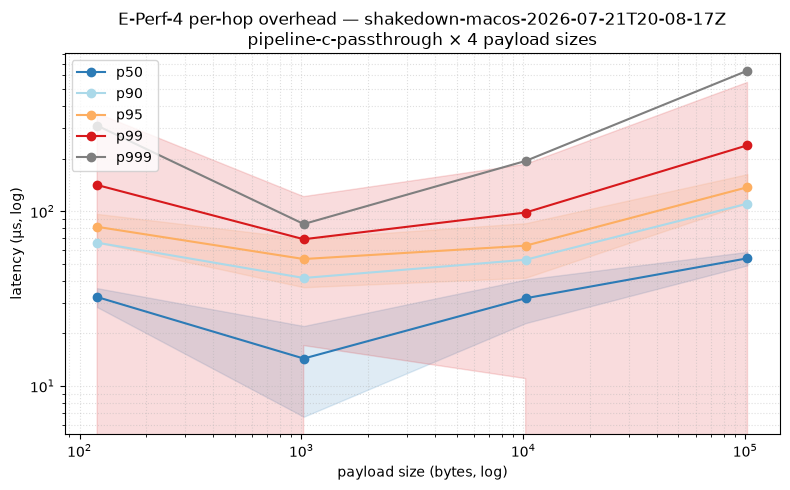

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {'p50': '#2c7bb6', 'p90': '#abd9e9', 'p95': '#fdae61', 'p99': '#d7191c', 'p999': '#7f7f7f'}
for pct in ['p50', 'p90', 'p95', 'p99', 'p999']:
    sub = df[df.percentile == pct].sort_values('size_bytes')
    if sub.empty:
        continue
    ax.plot(sub.size_bytes, sub.median_us, marker='o', label=pct, color=colors[pct])
    if pct in {'p50', 'p95', 'p99'}:
        ax.fill_between(sub.size_bytes,
                        sub.median_us - sub.stdev_us,
                        sub.median_us + sub.stdev_us,
                        alpha=0.15, color=colors[pct])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('payload size (bytes, log)')
ax.set_ylabel('latency (µs, log)')
ax.set_title(f'E-Perf-4 per-hop overhead — {shakedown_dir.name}\npipeline-c-passthrough × 4 payload sizes')
ax.grid(True, which='both', linestyle=':', alpha=0.4)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Sanity checks

- Every point should be positive and the confidence bands should not overlap zero.
- p50 should grow monotonically with payload size once the OS-scheduler noise floor is exceeded.
- p99/p999 stdev is expected to be large on macOS shakedown; the Pi canonical run should show tighter tails.

In [5]:
problems = []
for row in rows:
    if row['percentile'] == 'p50' and row['median_us'] <= 0:
        problems.append(f"non-positive p50 for {row['size_label']}")
if problems:
    print('SANITY:')
    for p in problems: print(' ', p)
else:
    print('SANITY: no red flags on p50 basics')

sizes_sorted = df[df.percentile == 'p50'].sort_values('size_bytes')
delta = sizes_sorted.median_us.diff().dropna()
print('\nΔ p50 median from 120b→1kb→10kb→100kb (µs):', delta.round(1).to_list())
if (delta < 0).any():
    print('  ⚠ p50 median went DOWN with increasing payload — likely macOS scheduler noise (cold-cache first size).')

SANITY: no red flags on p50 basics

Δ p50 median from 120b→1kb→10kb→100kb (µs): [-17.9, 17.4, 22.0]
  ⚠ p50 median went DOWN with increasing payload — likely macOS scheduler noise (cold-cache first size).
